In [48]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skopt import gp_minimize

In [49]:
data0 = pd.read_csv(r"D:\Ongoing\work at IUE\Paper\SAC\TNSE.csv", encoding='unicode_escape')
print(data0)

    M1  M2  Mass of M1  Oxidatation state No. of M1  Mass of M2  \
0   Cu  Ru        63.5                            4       101.1   
1   Cu  Rh        63.5                            4       102.9   
2   Zn  Ru        65.4                            2       101.1   
3   Zn  Rh        65.4                            2       102.9   
4   Ni  Ru        58.7                            5       101.1   
..  ..  ..         ...                          ...         ...   
85  Mn  Ir        54.9                           10       192.2   
86  Cu  Pt        63.5                            4       195.1   
87  Zn  Pt        65.4                            2       195.1   
88  Cu  Ir        63.5                            4       192.2   
89  Zn  Ir        65.4                            2       192.2   

    Oxidatation state No. of M2  M2/M1  Conversion (%)  C5-C22 yield (%)  \
0                             9    0.1       94.429000         45.112967   
1                             7    0.1     

In [57]:

X=data0.iloc[:,2:7]
y=data0.iloc[:,11]
print(y)

0     3
1     3
2     3
3     3
4     2
     ..
85    2
86    1
87    2
88    2
89    2
Name: Category, Length: 90, dtype: int64


In [60]:
#from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# # 加载数据
# iris = load_iris()
# X, y = iris.data, iris.target

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE降维
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


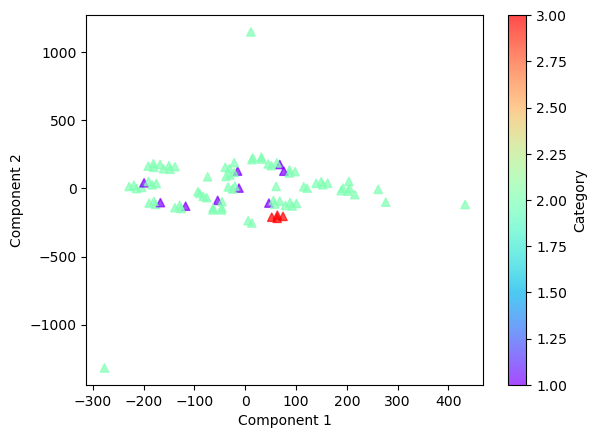

In [71]:

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7,c=y,cmap='rainbow',marker='^')#viridis,brg，jet,rainbow

#plt.title('t-SNE Visualization of Iris Dataset')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.colorbar(label='Category')
plt.show()

In [72]:
df = pd.DataFrame(X_tsne,columns=["Component 1","Component 2",])#
df.to_excel("TSNE_data-SAC.xlsx", index=False, sheet_name="Sheet1")